In [18]:
START1 = 2000
END1 = 2007
START2 = 2014
END2 = 2020

COUNTRIES = {
    'Belgium': [(START1, END1), (START2, END2)],
    #'Germany': [(START1, END1), (START2, END2)], #very low data coverage
    'Italy': [(START1, END1), (START2, END2)],
    'Portugal': [None, (START2, END2)], #no data for first period
    'Spain':[(START1, END1), (START2, END2)],
    'Sweden': [(START1, END1), (START2, END2)]

}

In [19]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["cmr10", "Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,   # use ASCII hyphen instead of Unicode minus
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

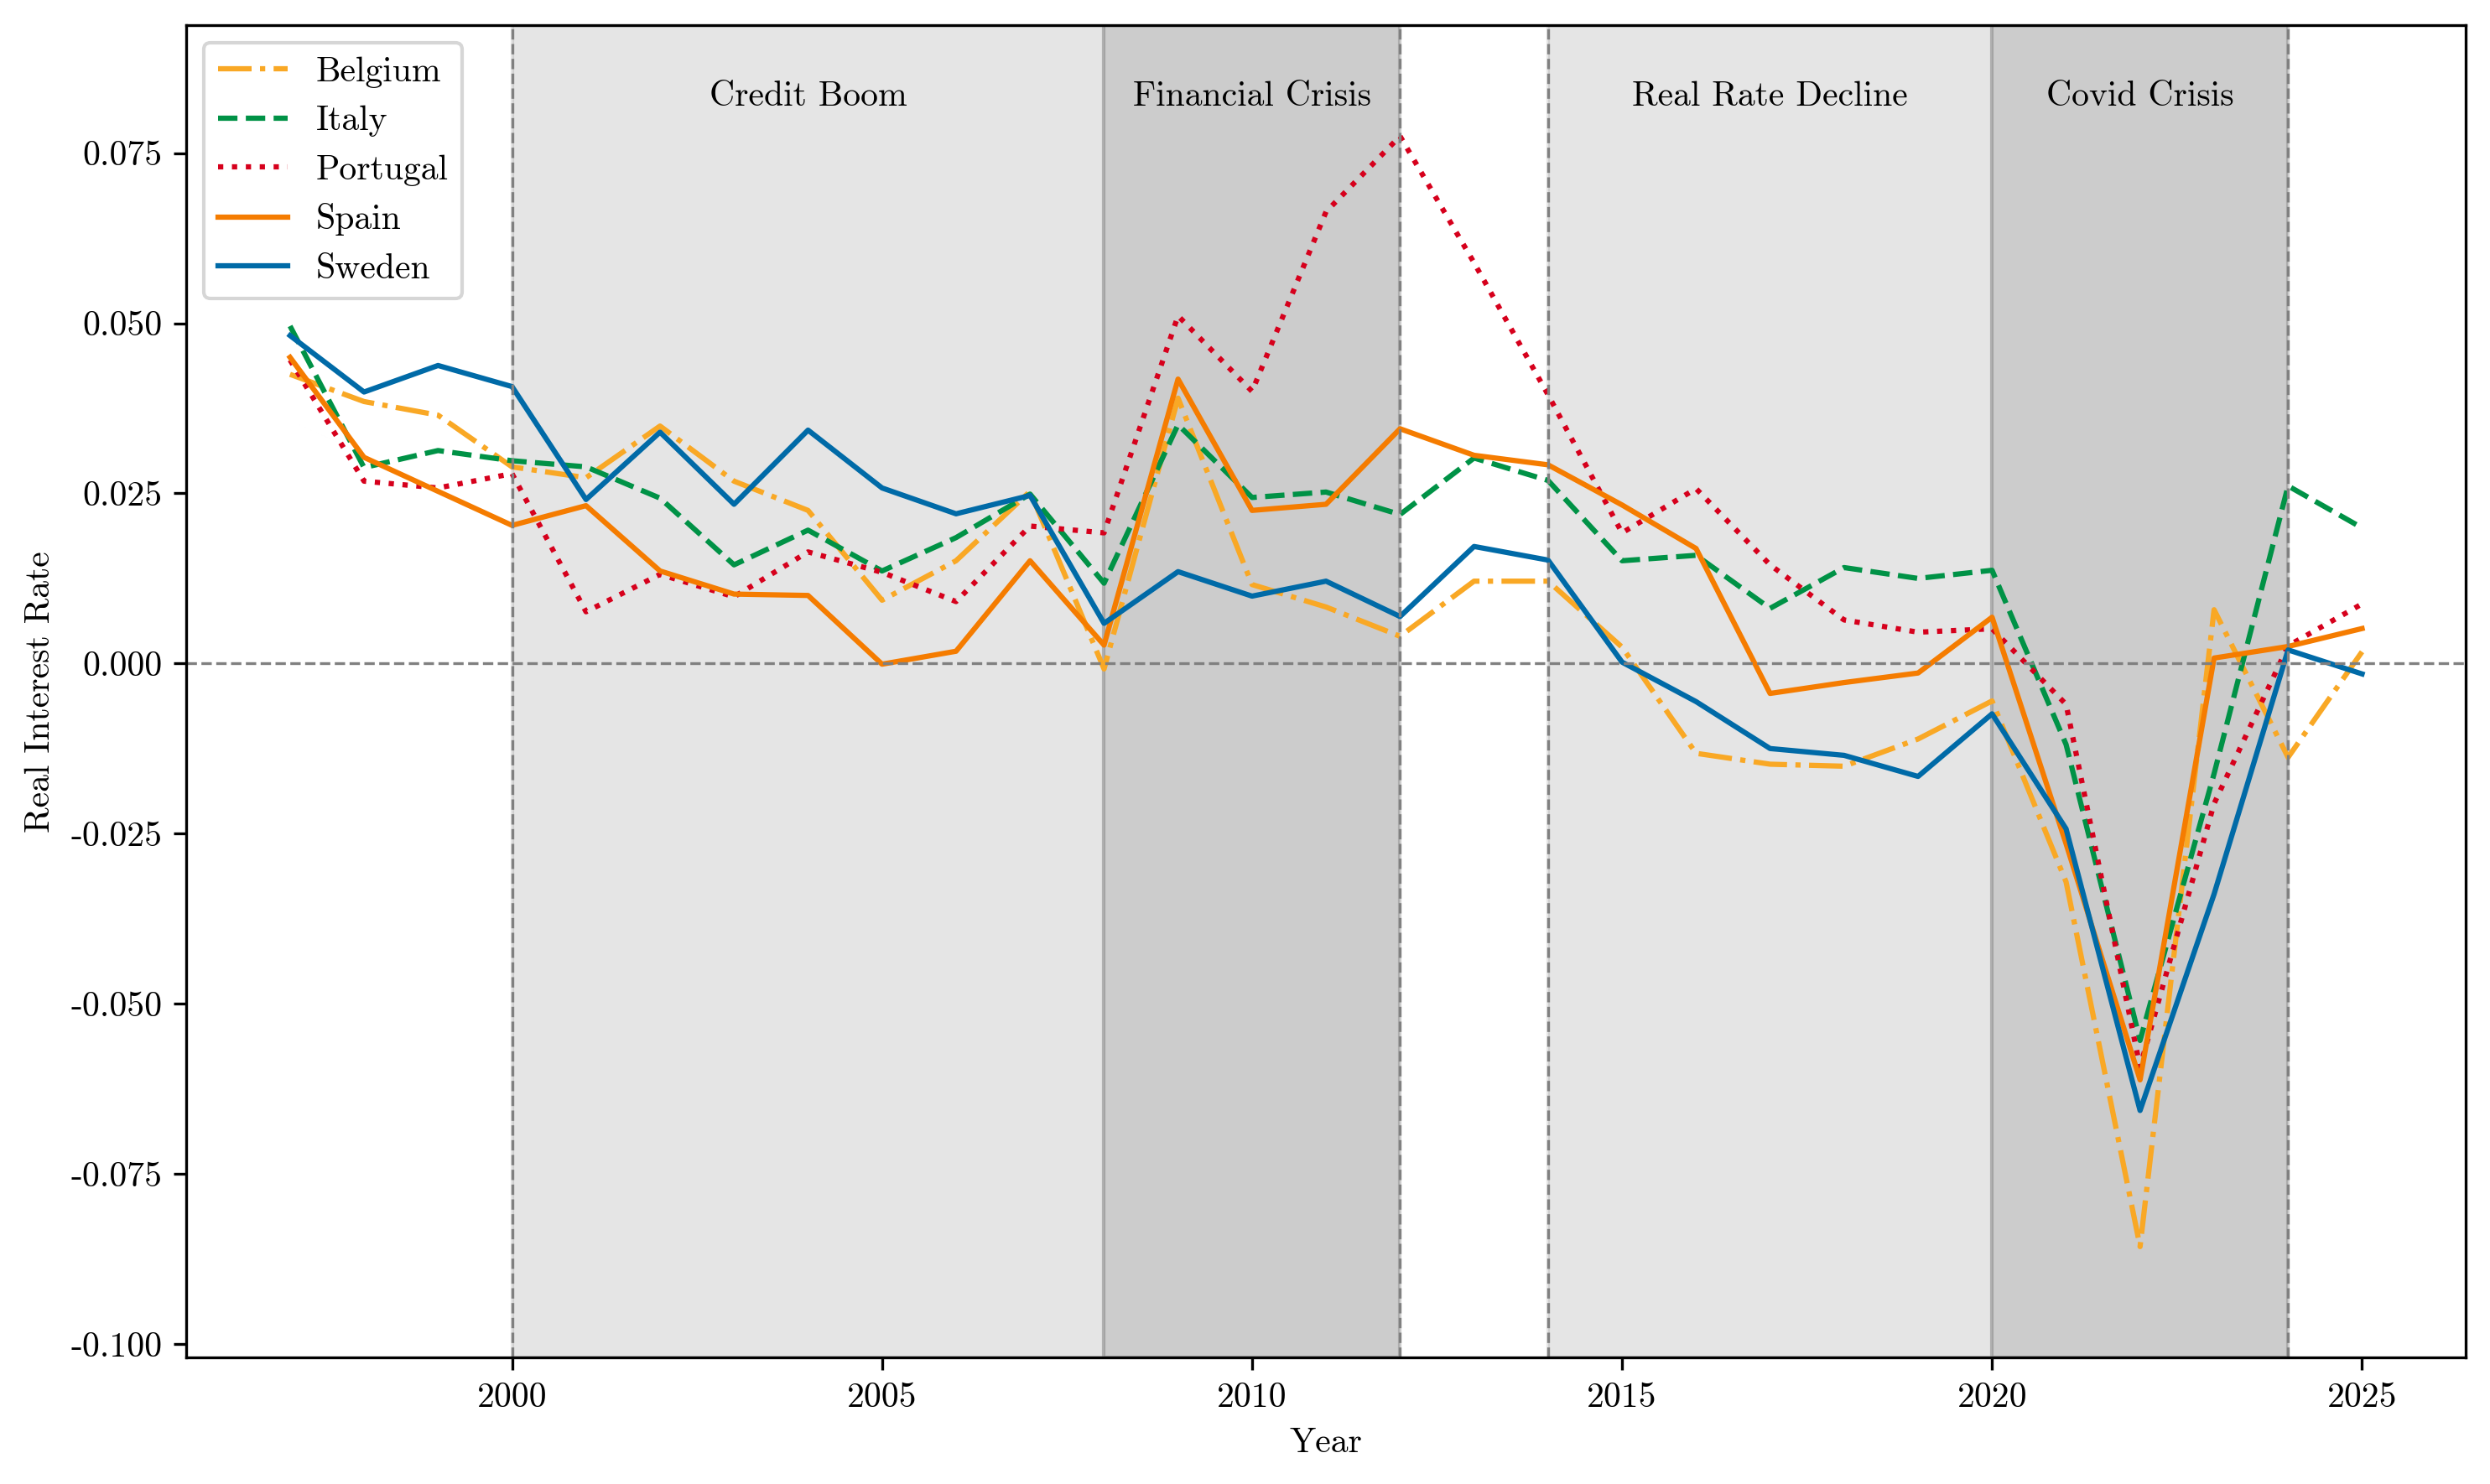

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from modules.RealRate import RealRate
from CompareCountries import COUNTRY_STYLES

df = pd.DataFrame()
for country in COUNTRIES.keys():
    rr = RealRate(country)
    df = pd.concat([df, rr.df], axis=0, ignore_index=True)



fig, ax = plt.subplots(figsize=(10, 6))

for country, g in df.groupby('country'):
    color = COUNTRY_STYLES.get(country)['color']
    linestyle = COUNTRY_STYLES.get(country)['linestyle']
    ax.plot(g['year'], g['realinterestrate'], color=color, label=country, linestyle=linestyle)

ax.axvline(2000, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(2012, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(2014, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(2024, color='grey', linewidth=0.8, linestyle='--')

ax.axvspan(2000, 2008, color='gray', alpha=0.2)
ax.text((2000 + 2008) / 2, ax.get_ylim()[1], 'Credit Boom', ha='center', va='top')

ax.axvspan(2008, 2012, color='gray', alpha=0.4)
ax.text((2008 + 2012) / 2, ax.get_ylim()[1], 'Financial Crisis', ha='center', va='top')

ax.axvspan(2014, 2020, color='gray', alpha=0.2)
ax.text((2014 + 2020) / 2, ax.get_ylim()[1], 'Real Rate Decline', ha='center', va='top')

ax.axvspan(2020, 2024, color='gray', alpha=0.4)
ax.text((2020 + 2024) / 2, ax.get_ylim()[1], 'Covid Crisis', ha='center', va='top')


ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Year')
ax.set_ylabel('Real Interest Rate')
ax.legend()
ax.margins(x=0.05, y=0.1)  
fig.tight_layout()
plt.show()

fig.savefig('plots/realinterestrate.png', dpi=300)


In [21]:
from CompareCountries import CompareCountries
from MisallocationAnalysis import MisallocationAnalysis

allanalises = []

for country, rangelist in COUNTRIES.items():
    for range in rangelist:
        if range == None:
            continue
        analysis = MisallocationAnalysis(country, range[0], range[1], sector='C')
        allanalises.append(analysis)



In [22]:
import CompareCountries
import importlib
importlib.reload(CompareCountries)

from CompareCountries import CompareCountries
comparison = CompareCountries(allanalises)

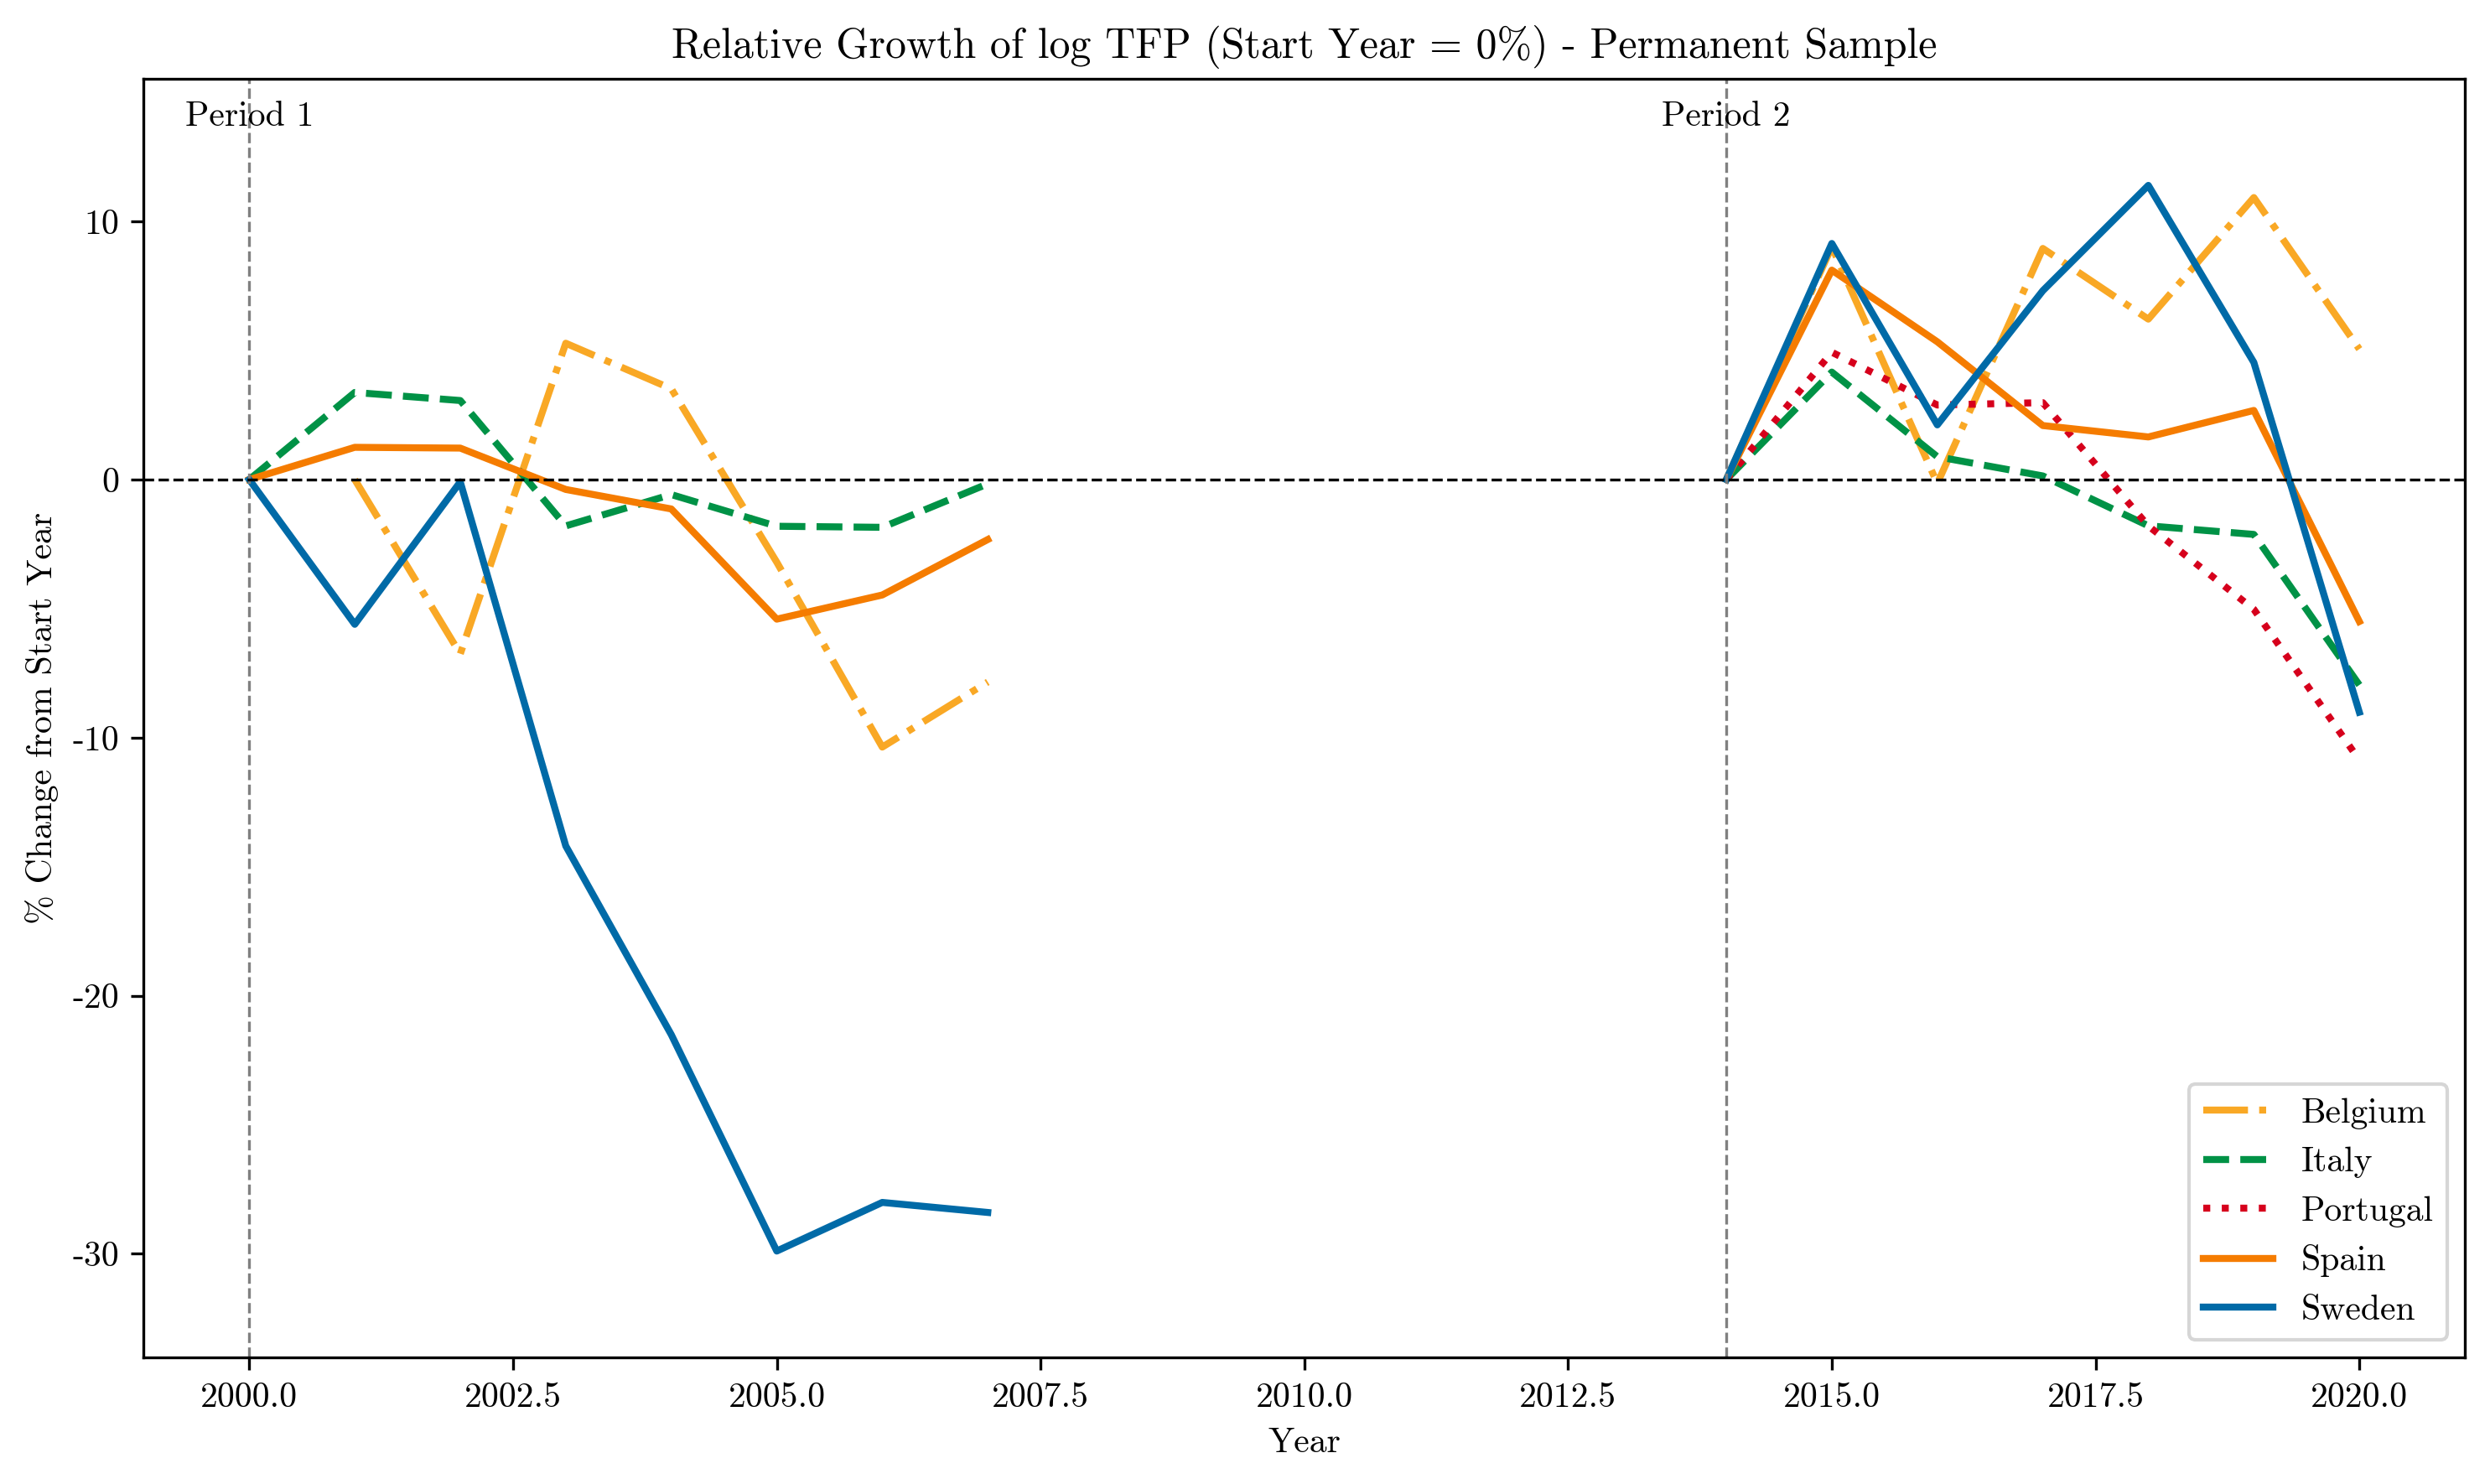

In [23]:
tfpplot = comparison.plot_compare_sectoral_tfp('permanent')
#tfpplot.savefig('plots/countries_tfp_permanent.png', dpi=300)

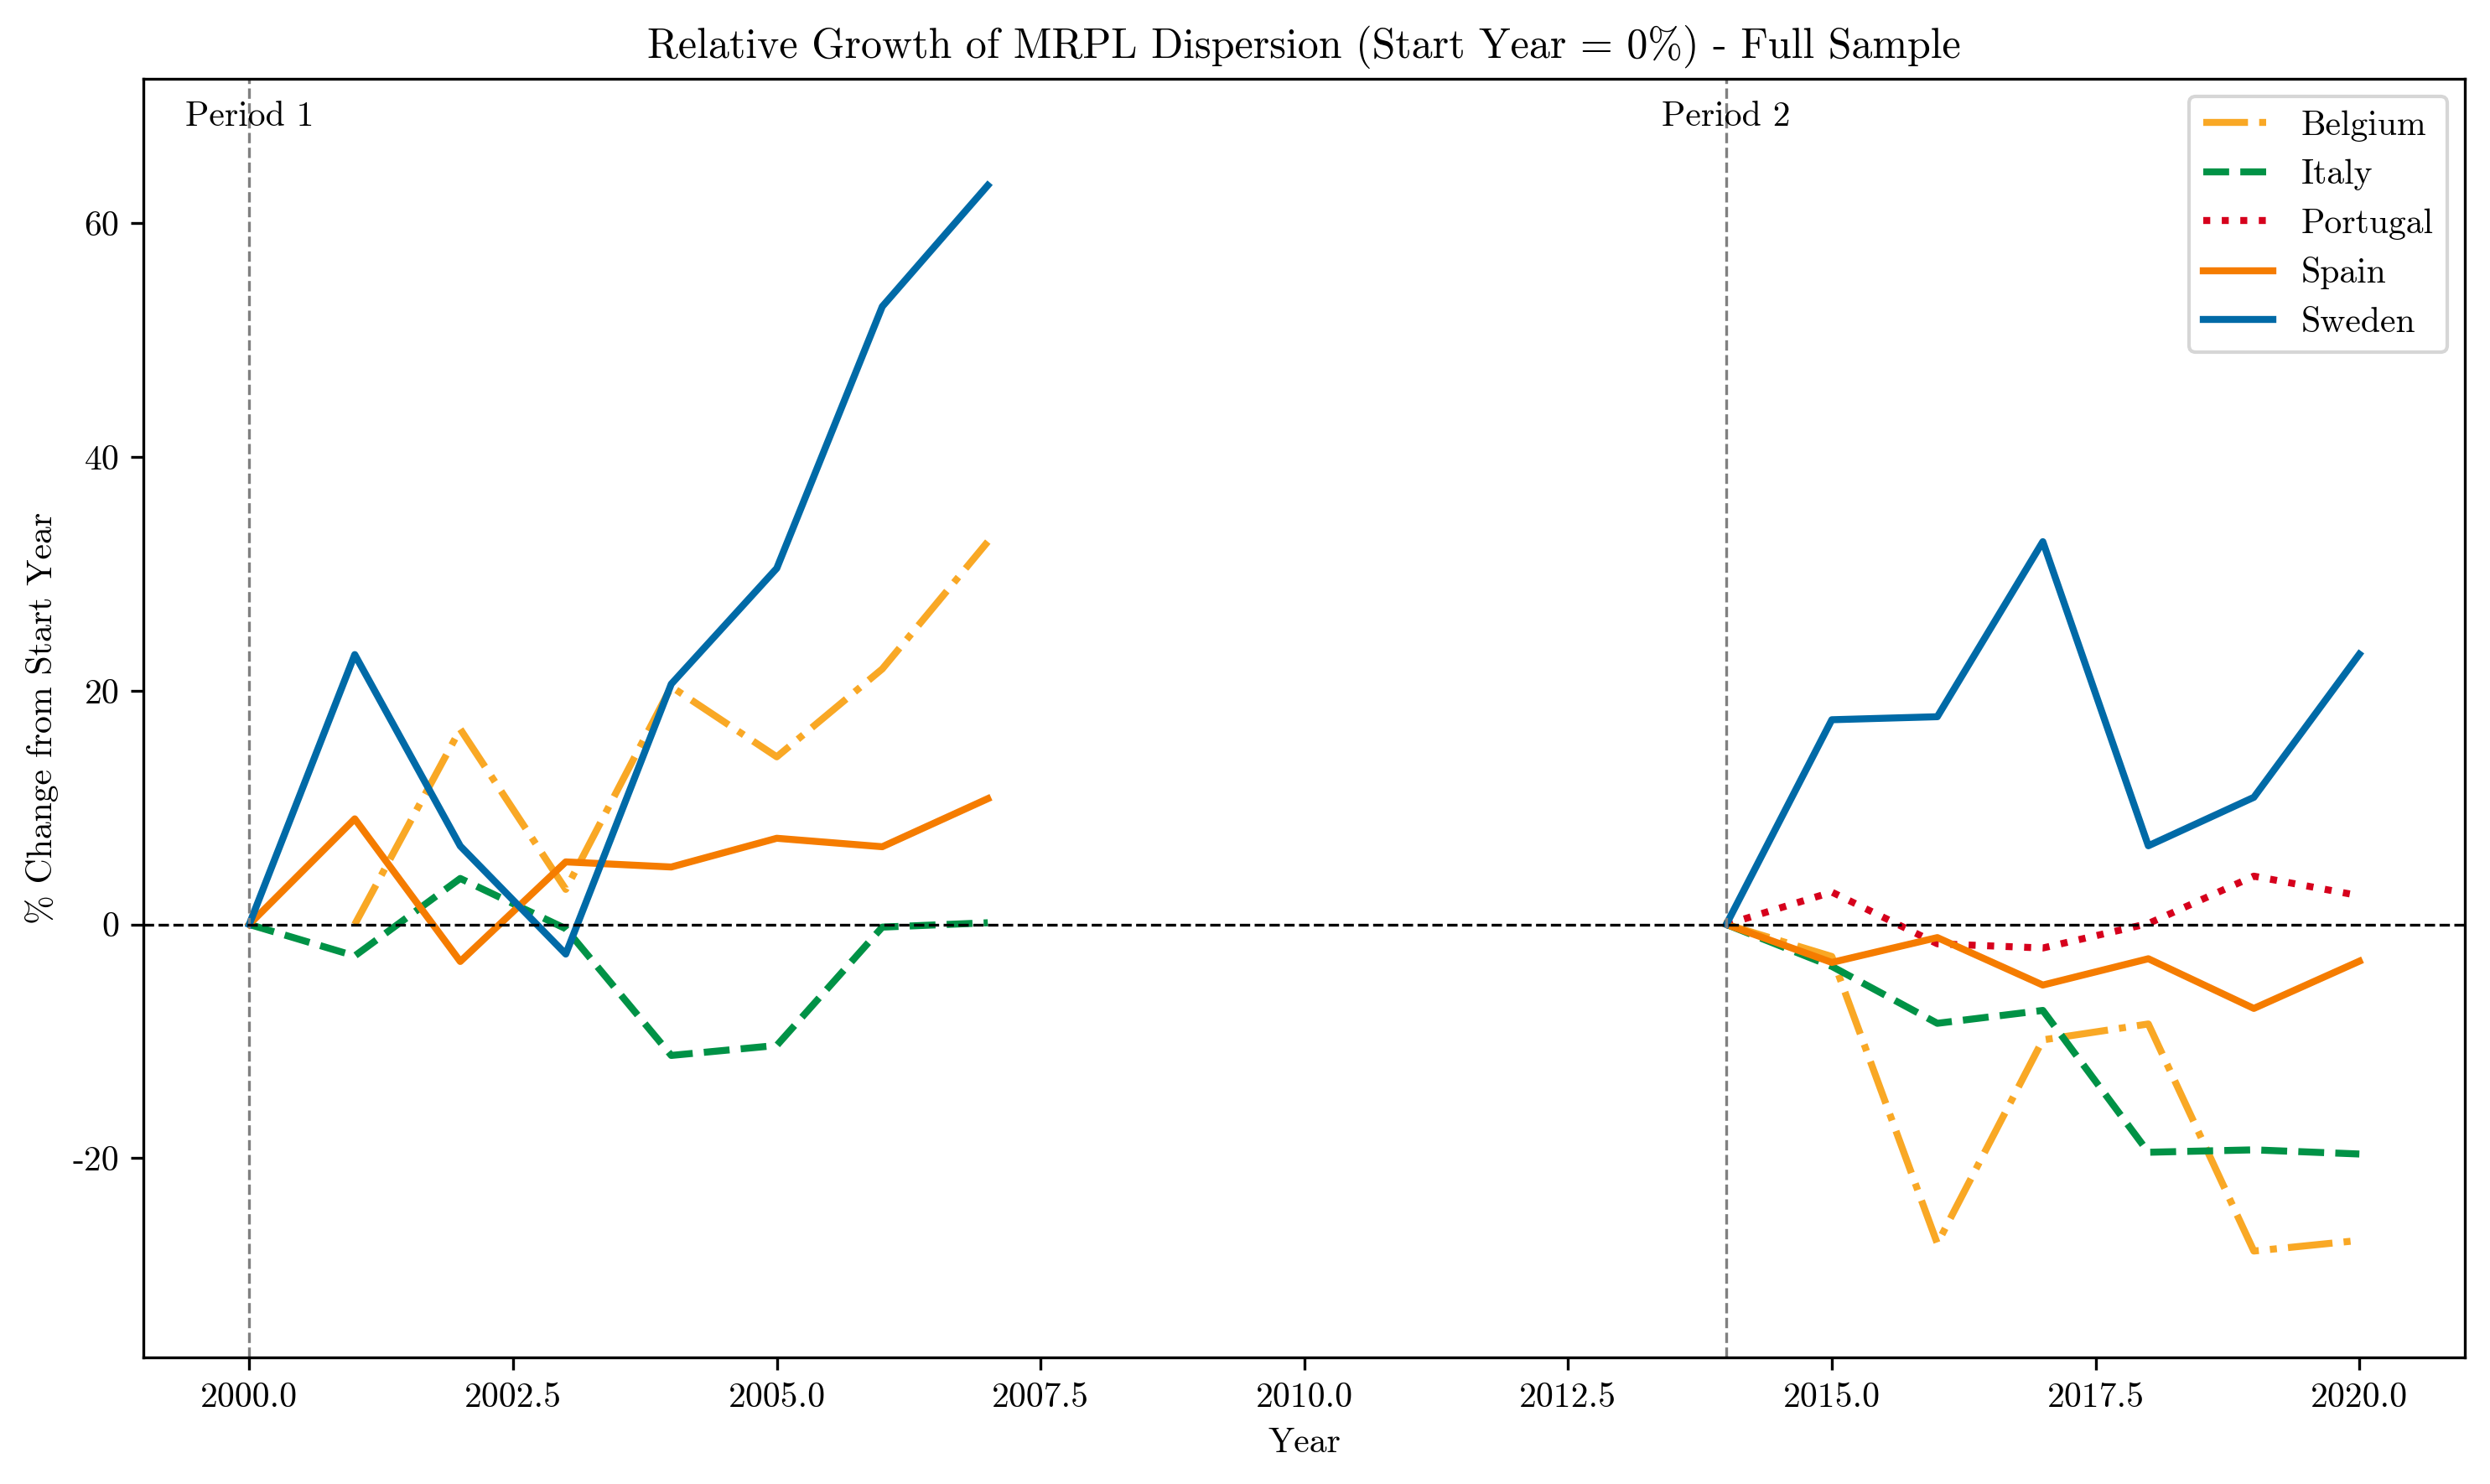

In [24]:

variable = 'MRPL'
countriesmrpkplot = comparison.plot_compare_factor_products(figsize=(10,6),variable=variable,sample='full')
countriesmrpkplot.savefig(f'plots/countries_{variable.lower()}_full.png', dpi=300)



In [25]:
print(comparison.compare(sample='full')[['Country','Time', 'Revenue Data Coverage %']])

    Country         Time  Revenue Data Coverage %
0   Belgium  2000 - 2007                    32.50
1   Belgium  2014 - 2020                    33.43
2     Italy  2000 - 2007                    23.12
3     Italy  2014 - 2020                    39.57
4  Portugal  2014 - 2020                    38.57
5     Spain  2000 - 2007                    44.75
6     Spain  2014 - 2020                    60.00
7    Sweden  2000 - 2007                     9.88
8    Sweden  2014 - 2020                    11.57


In [26]:
MOMENTS = ['Top 20% Share of k', 'Coef log_a on capital growth', 'Corr (log MRPK, log k)', 'Corr (log MRPK, log Z)']

print(comparison.compare_all_moments().loc[MOMENTS].to_latex())

\begin{tabular}{lrrrrrrrrr}
\toprule
 & Belgium 2000-2007 & Belgium 2014-2020 & Italy 2000-2007 & Italy 2014-2020 & Portugal 2014-2020 & Spain 2000-2007 & Spain 2014-2020 & Sweden 2000-2007 & Sweden 2014-2020 \\
\midrule
Top 20% Share of k & 0.840000 & 0.870000 & 0.710000 & 0.820000 & 0.860000 & 0.820000 & 0.850000 & 0.910000 & 0.850000 \\
Coef log_a on capital growth & 0.056000 & 0.040000 & -3.014000 & 0.006000 & 0.057000 & 0.033000 & 0.048000 & 0.078000 & 0.008000 \\
Corr (log MRPK, log k) & -0.280000 & -0.330000 & -0.250000 & -0.260000 & -0.290000 & -0.480000 & -0.390000 & -0.340000 & -0.290000 \\
Corr (log MRPK, log Z) & 0.380000 & 0.390000 & 0.360000 & 0.290000 & 0.330000 & 0.070000 & 0.310000 & 0.180000 & 0.240000 \\
\bottomrule
\end{tabular}



### Capital Wedges

In [27]:
analysis = MisallocationAnalysis('Portugal', 2007, 2024, sector='C')
analysis.compare_df_eurostats()

,Year,Turnover,Wages,Value Added,Firms,Employees
0,2007,0.32,NaN,0.56,0.12,0.32
1,2008,0.34,0.48,0.61,0.13,0.32
2,2009,0.37,0.50,0.66,0.13,0.33
3,2010,0.36,0.48,0.62,0.13,0.32
4,2011,0.37,0.47,0.65,0.13,0.32
5,2012,0.32,0.45,0.62,0.13,0.32
6,2013,0.39,0.51,0.67,0.13,0.36
7,2014,0.38,0.52,0.72,0.14,0.35
8,2015,0.43,0.55,0.72,0.14,0.39
9,2016,0.38,0.50,0.65,0.15,0.35


In [28]:
START = 2000
END = 2024

COUNTRIES = [
    'Belgium',
    'Italy',
    'Portugal',
    'Sweden'
]

allanalises = []

for country in COUNTRIES:
        if country == 'Portugal':
              start = 2007
        else: start = START
        analysis = MisallocationAnalysis(country, start, END, sector='C')
        allanalises.append(analysis)

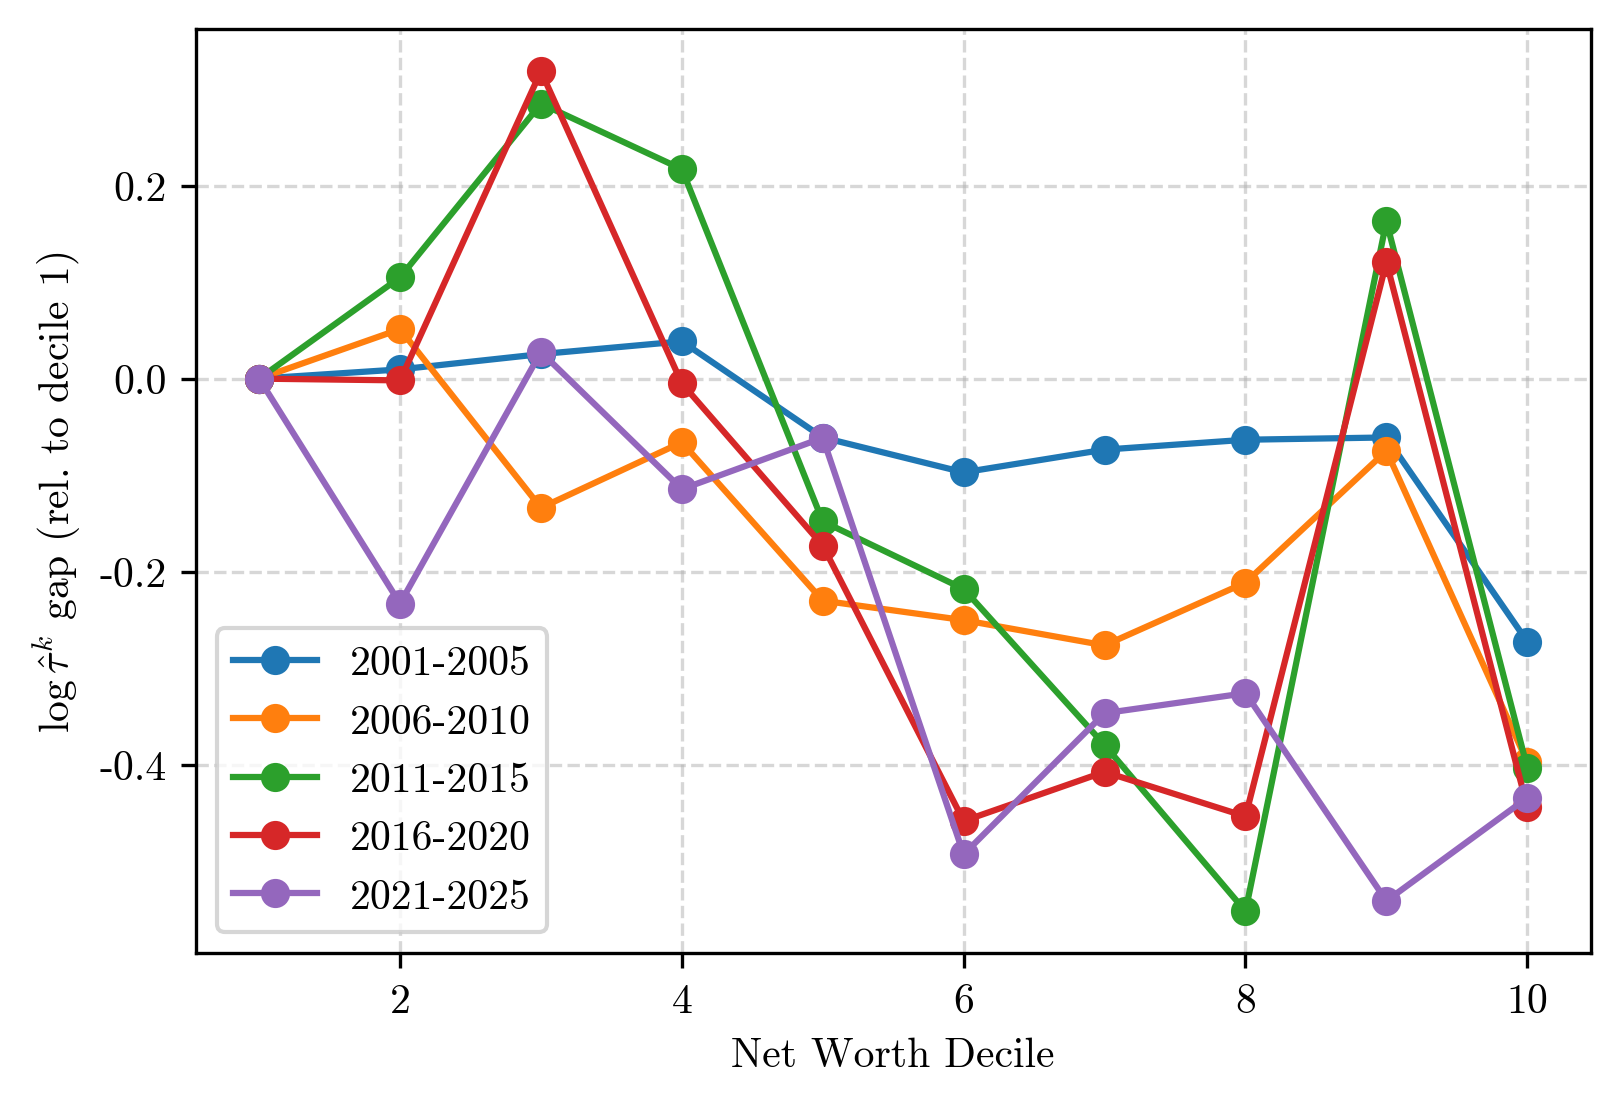

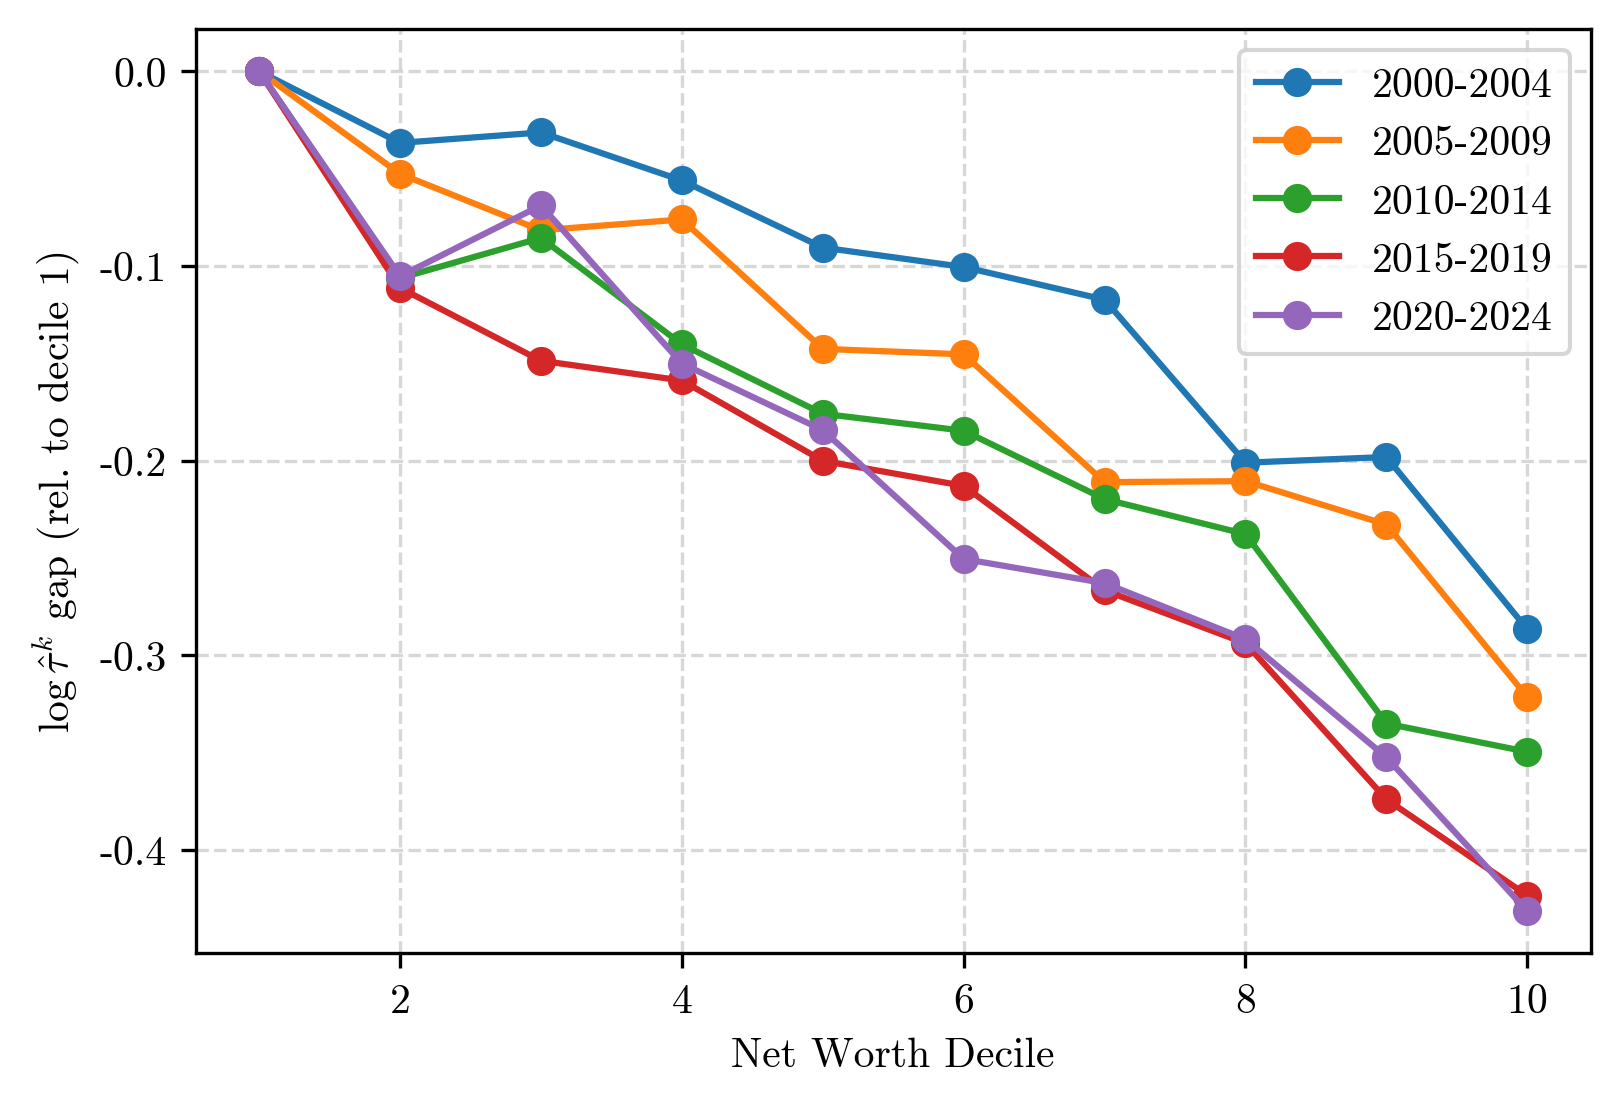

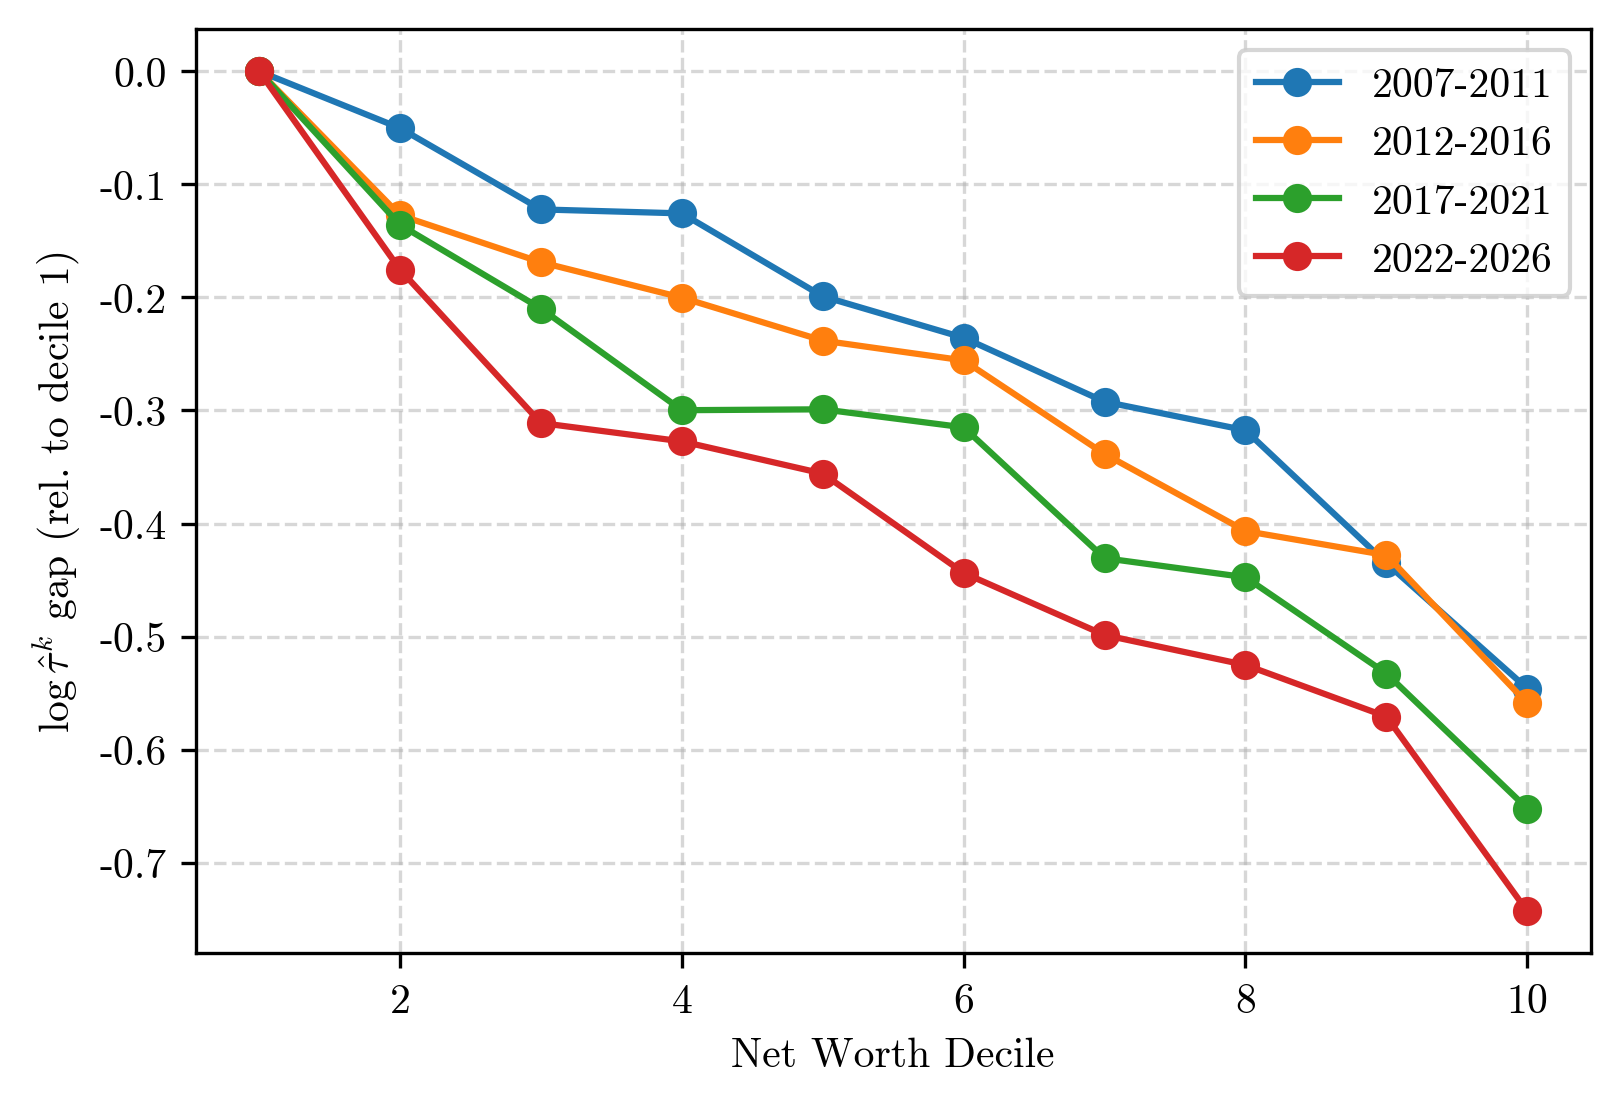

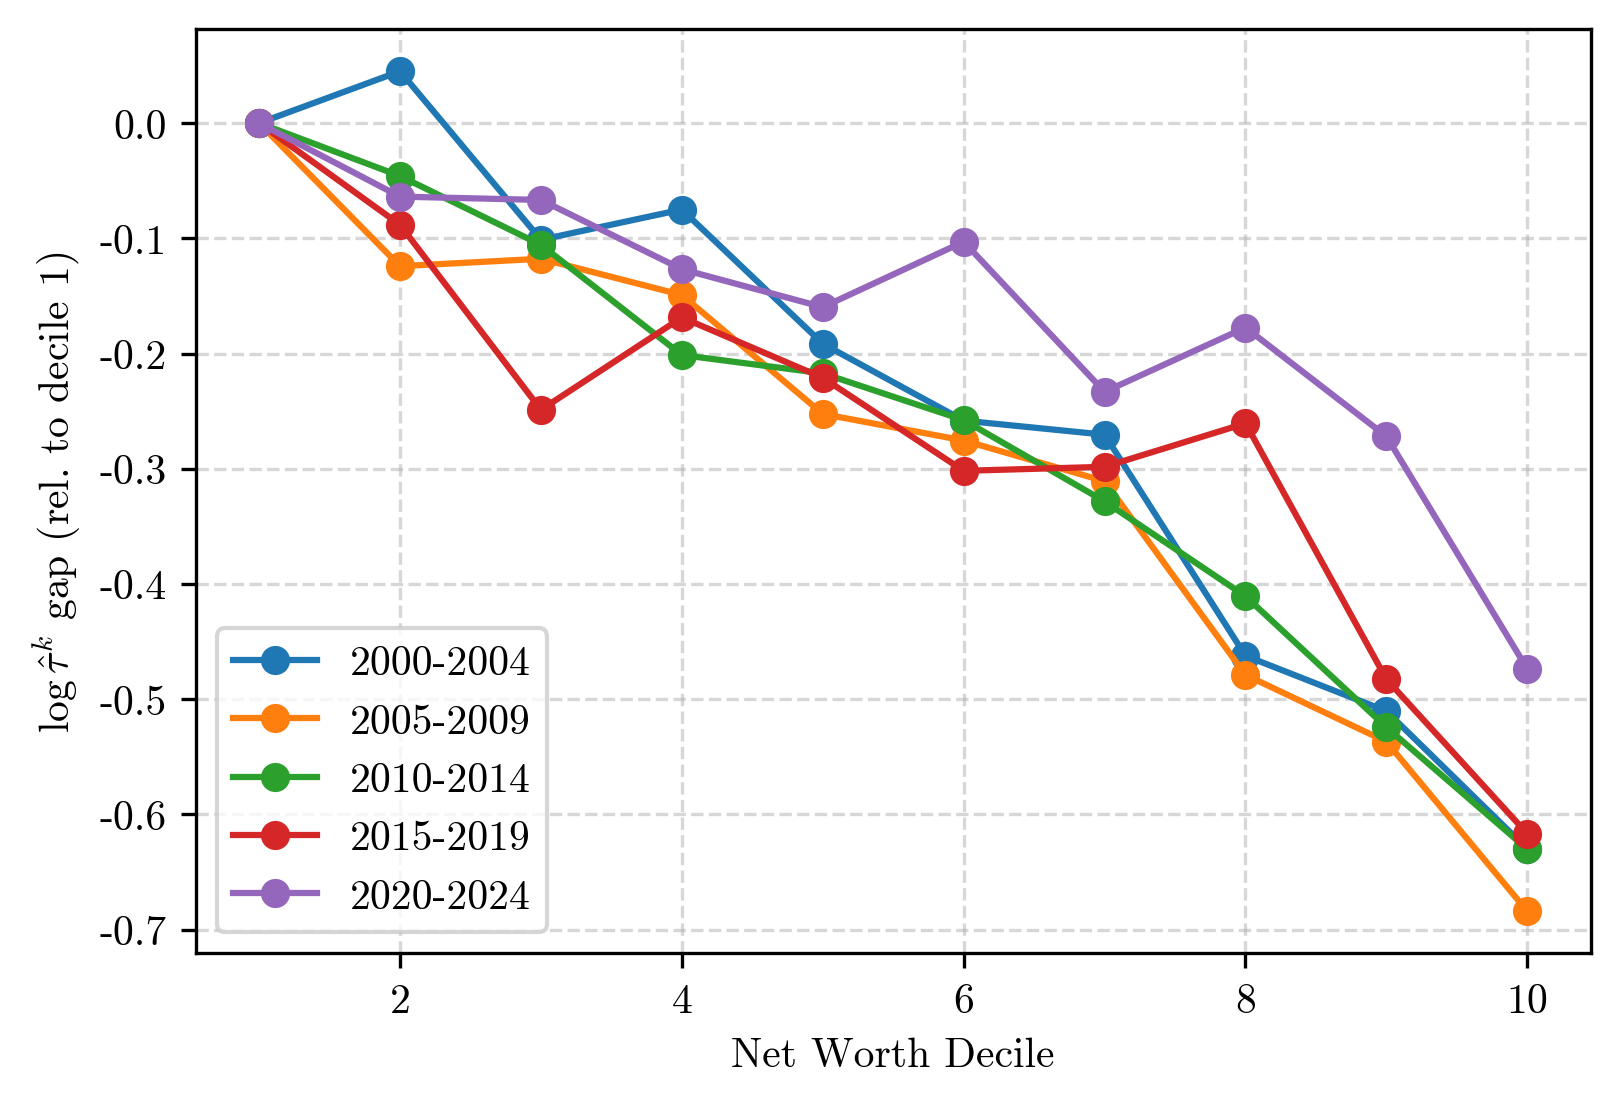

In [29]:

for country in allanalises:
    fig = country.plot_capital_wedges_results()
    fig.savefig(f'plots/countrywedges/capital_wedges_firm_size_{country.country}.png',dpi=300)